In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crnn-data/CRNN_data/crnn_data_anno.csv
/kaggle/input/crnn-data/CRNN_data/Cropped_images/1269.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/623.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/2193.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/2008.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/2081.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/764.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/1700.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/1786.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/2907.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/1075.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/2863.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/771.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/208.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/2628.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/820.jpg
/kaggle/input/crnn-data/CRNN_data/Cropped_images/1789.jpg
/kaggle/input/crnn-data/

In [2]:
import os, cv2, numpy as np, pandas as pd, editdistance, shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau

# Charset & dataset
CHARSET = "0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZΩµ.-∠"
char_to_idx = {c: i for i, c in enumerate(CHARSET)}
idx_to_char = {i: c for i, c in enumerate(CHARSET)}
num_classes = len(CHARSET) + 1  # +1 for CTC blank

data_path = "/kaggle/input/crnn-data/CRNN_data/crnn_data_anno.csv"
image_dir = "/kaggle/input/crnn-data/CRNN_data/Cropped_images"

data = pd.read_csv(data_path, header=None, names=["image_name", "text"])
data["text"] = data["text"].astype(str)


2025-10-03 16:08:20.157525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759507700.451357      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759507700.536888      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def preprocess_image(path, size=(128, 32)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size) / 255.0
    return np.expand_dims(img, -1)

images, texts = [], []
for _, row in data.iterrows():
    img_path = os.path.join(image_dir, row["image_name"])
    if os.path.exists(img_path):
        images.append(preprocess_image(img_path))
        texts.append(row["text"])

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(images, texts, test_size=0.2, random_state=42)


In [4]:
def encode_text(txt):
    return [char_to_idx[c] for c in txt if c in char_to_idx]

y_train_enc = [encode_text(t) for t in y_train]
y_val_enc = [encode_text(t) for t in y_val]

max_len = max(len(x) for x in y_train_enc)
y_train_pad = pad_sequences(y_train_enc, maxlen=max_len, padding="post", value=-1)
y_val_pad = pad_sequences(y_val_enc, maxlen=max_len, padding="post", value=-1)


In [5]:
def build_crnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape, name="input_image")
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Reshape((input_shape[1]//4, -1))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return models.Model(inp, out)

input_shape = (32,128,1)
crnn_model = build_crnn(input_shape, num_classes)
crnn_model.summary(line_length=120)


2025-10-03 16:11:36.026341: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_image (InputLayer)                            │ (None, 32, 128, 1)                     │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d (Conv2D)                                     │ (None, 32, 128, 32)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ max_pooling2d (MaxPooling2D)                        │ (None, 16, 64, 32)                     │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_1 (Conv2D)                                   │ (None, 16, 64, 64)                     │                18,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ max_pooling2d_1 (MaxPooling2D)                      │ (None, 8, 32, 64)                      │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ reshape (Reshape)                                   │ (None, 32, 512)                        │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bidirectional (Bidirectional)                       │ (None, 32, 256)                        │               656,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization (BatchNormalization)            │ (None, 32, 256)                        │                 1,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bidirectional_1 (Bidirectional)                     │ (None, 32, 256)                        │               394,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_1 (BatchNormalization)          │ (None, 32, 256)                        │                 1,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ predictions (Dense)                                 │ (None, 32, 68)                         │                17,
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 1,088,964 (4.15 MB)

 Trainable params: 1,087,940 (4.15 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [6]:
labels = layers.Input(name="labels", shape=(max_len,), dtype="int32")
inp_len = layers.Input(name="input_length", shape=(1,), dtype="int32")
lab_len = layers.Input(name="label_length", shape=(1,), dtype="int32")

loss_out = layers.Lambda(lambda x: K.ctc_batch_cost(*x), name="ctc")(
    [labels, crnn_model.output, inp_len, lab_len]
)

model_train = models.Model([crnn_model.input, labels, inp_len, lab_len], loss_out)
model_train.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                    loss={"ctc": lambda y_true, y_pred: y_pred})


In [8]:
def decode_batch(model, X_batch):
    y_pred = model.predict(np.array(X_batch))
    decoded, _ = K.ctc_decode(y_pred, input_length=np.ones(y_pred.shape[0])*y_pred.shape[1], greedy=True)
    return decoded[0].numpy()

class CERCallback(tf.keras.callbacks.Callback):
    def __init__(self, model, X, Y, Xv, Yv, sample_size=200):
        self.infer_model = model; self.X, self.Y = X, Y; self.Xv, self.Yv = Xv, Yv
        self.sample_size = sample_size
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        val_preds = decode_batch(self.infer_model, self.Xv[:self.sample_size])
        cer = 0
        for gt, seq in zip(self.Yv[:self.sample_size], val_preds):
            pr = "".join([CHARSET[c] for c in seq if c != -1 and c < len(CHARSET)])
            cer += editdistance.eval(gt, pr) / max(1,len(gt))
        cer /= self.sample_size
        logs["val_cer"] = cer
        self.history.append((epoch, cer))
        print(f"Epoch {epoch+1} CER: {cer:.4f}")


In [9]:
train_inp_len = np.full((len(X_train),1), crnn_model.output_shape[1])
val_inp_len = np.full((len(X_val),1), crnn_model.output_shape[1])
train_lab_len = np.array([len(x) for x in y_train_enc]).reshape(-1,1)
val_lab_len = np.array([len(x) for x in y_val_enc]).reshape(-1,1)

dummy_train = np.zeros((len(X_train),1))
dummy_val = np.zeros((len(X_val),1))

# Callbacks
cer_cb = CERCallback(crnn_model, X_train, y_train, X_val, y_val)
csv_logger = CSVLogger("/kaggle/working/training_log.csv", append=False)
ckpt = ModelCheckpoint("/kaggle/working/best_model.weights.h5", monitor="val_loss",
                       save_best_only=True, save_weights_only=True, verbose=1)

history = model_train.fit(
    x=[np.array(X_train), y_train_pad, train_inp_len, train_lab_len],
    y=dummy_train,
    validation_data=([np.array(X_val), y_val_pad, val_inp_len, val_lab_len], dummy_val),
    batch_size=32,
    epochs=50,
    callbacks=[csv_logger, ckpt, cer_cb]
)


Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 30.7817
Epoch 1: val_loss improved from inf to 20.32936, saving model to /kaggle/working/best_model.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step
Epoch 1 CER: 0.7900
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 319ms/step - loss: 30.5930 - val_loss: 20.3294 - val_cer: 0.7900
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 6.3537
Epoch 2: val_loss improved from 20.32936 to 15.20249, saving model to /kaggle/working/best_model.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Epoch 2 CER: 0.8563
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - loss: 6.3462 - val_loss: 15.2025 - val_cer: 0.8562
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 4.2652
Epoch 3: val_loss improved from 15.20249 to 15.18598, saving model to /kaggle/working/best_model.weights.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Epoch 3 CER: 0.9317
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 272ms/step - loss: 4.2646 - val_loss: 15.1860 - val_cer: 0.9317
Epoch 4/50
75/75 ━

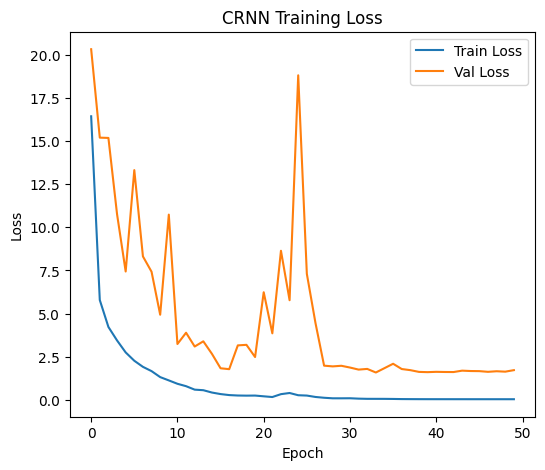

✅ Final Validation CER: 0.0647


In [10]:
# Reload best weights
crnn_model.load_weights("/kaggle/working/best_model.weights.h5")

# Plot training + val loss as .svg
df = pd.read_csv("/kaggle/working/training_log.csv")
plt.figure(figsize=(6,5))
plt.plot(df["epoch"], df["loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("CRNN Training Loss")
plt.savefig("/kaggle/working/crnn_loss_curve.svg", format="svg", bbox_inches="tight")
plt.show()

# Final CER
final_cer = cer_cb.history[-1][1]
print(f"✅ Final Validation CER: {final_cer:.4f}")


In [11]:
crnn_model.save("/kaggle/working/crnn_inference_model.h5")
shutil.make_archive("/kaggle/working/crnn_outputs", "zip", "/kaggle/working/")
print("📦 All outputs saved to crnn_outputs.zip")


Traceback (most recent call last):
  File "/usr/lib/python3.11/zipfile.py", line 1815, in write
    shutil.copyfileobj(src, dest, 1024*8)
  File "/usr/lib/python3.11/shutil.py", line 200, in copyfileobj
    fdst_write(buf)
  File "/usr/lib/python3.11/zipfile.py", line 1178, in write
    data = self._compressor.compress(data)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_36/387489689.py", line 2, in <cell line: 0>
    shutil.make_archive("/kaggle/working/crnn_outputs", "zip", "/kaggle/working/")
  File "/usr/lib/python3.11/shutil.py", line 1165, in make_archive
    filename = func(base_name, base_dir, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/

TypeError: object of type 'NoneType' has no len()

In [12]:
from tensorflow.keras.models import load_model

# Load your saved CRNN inference model
crnn_model = load_model("/kaggle/working/crnn_inference_model.h5", compile=False)


In [13]:
def decode_prediction(pred, charset=CHARSET):
    decoded, _ = K.ctc_decode(pred,
                              input_length=np.ones(pred.shape[0]) * pred.shape[1],
                              greedy=True)
    decoded = decoded[0].numpy()
    texts = []
    for seq in decoded:
        text = "".join([charset[c] for c in seq if c != -1 and c < len(charset)])
        texts.append(text)
    return texts


In [15]:
import pandas as pd, os
from sklearn.model_selection import train_test_split

# Reload dataset
data_path = "/kaggle/input/crnn-data/CRNN_data/crnn_data_anno.csv"
image_dir = "/kaggle/input/crnn-data/CRNN_data/Cropped_images"

data = pd.read_csv(data_path, header=None)
data.columns = ["image_name", "text"]
data["text"] = data["text"].astype(str)

# Rebuild images and labels
images, texts = [], []
for _, row in data.iterrows():
    img_path = os.path.join(image_dir, row["image_name"])
    if os.path.exists(img_path):
        img = preprocess_image(img_path)   # reuse your preprocessing function
        images.append(img)
        texts.append(row["text"])

# Redo split
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    images, texts, test_size=0.2, random_state=42
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


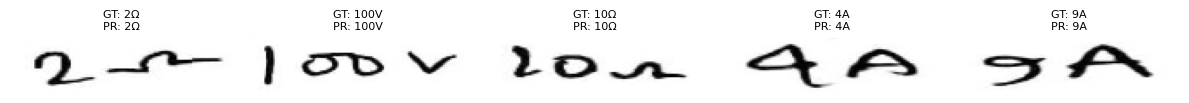

In [17]:
import random
import matplotlib.pyplot as plt

# Randomly pick 5 samples from validation
indices = random.sample(range(len(X_val)), 5)

plt.figure(figsize=(12,6))
for i, idx in enumerate(indices):
    img = X_val[idx]
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(img, axis=0))
    pred_text = decode_prediction(pred)[0]

    # Plot
    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"GT: {gt_text}\nPR: {pred_text}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/crnn_sample_predictions.svg", format="svg", bbox_inches="tight")
plt.show()


In [18]:
import matplotlib.pyplot as plt
from matplotlib.table import Table
import random

# Pick 5 validation samples
indices = random.sample(range(len(X_val)), 5)

# Prepare figure
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

# Create table
tbl = Table(ax, bbox=[0,0,1,1])

# Column labels
col_labels = ["Image", "Predicted Text", "Ground Truth"]
cell_text = []

# Row height and col width
row_height = 1 / (len(indices) + 1)
col_widths = [0.4, 0.3, 0.3]

# Add header
for j, label in enumerate(col_labels):
    tbl.add_cell(0, j, col_widths[j], row_height, text=label,
                 loc="center", facecolor="#cccccc")

# Add rows with images + texts
for i, idx in enumerate(indices):
    img = X_val[idx].squeeze()
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(img, axis=(0,-1)))
    pred_text = decode_prediction(pred)[0]

    # First col: image
    ax_img = plt.imshow(img, cmap="gray")
    plt.close()  # close extra image display

    tbl.add_cell(i+1, 0, col_widths[0], row_height, 
                 text="", loc="center")
    # attach image to cell
    tbl[i+1,0].get_text().set_visible(False)
    tbl[i+1,0]._text = None
    tbl[i+1,0]._loc = 'center'
    tbl[i+1,0]._image = img

    # Col 2: prediction
    tbl.add_cell(i+1, 1, col_widths[1], row_height, 
                 text=pred_text, loc="center")

    # Col 3: ground truth
    tbl.add_cell(i+1, 2, col_widths[2], row_height, 
                 text=gt_text, loc="center")

# Auto adjust
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor("black")

ax.add_table(tbl)

# Save as SVG
plt.savefig("/kaggle/working/crnn_predictions_table.svg", format="svg", bbox_inches="tight")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


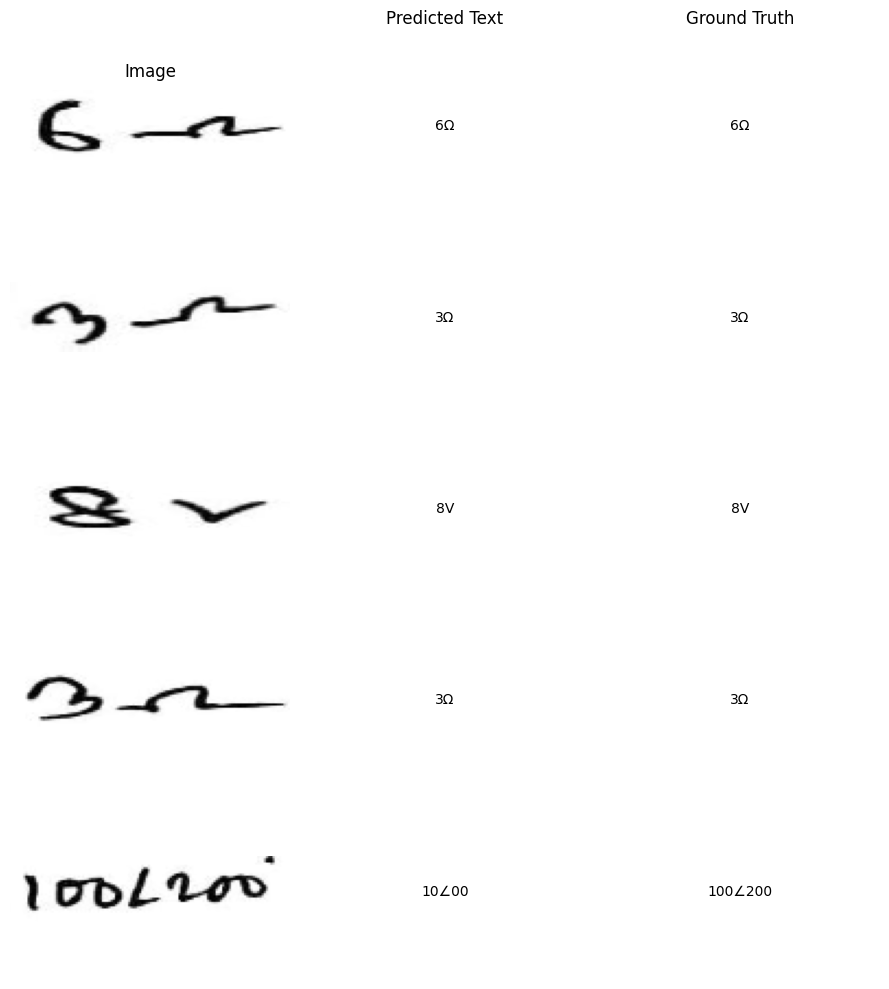

In [19]:
import random
import matplotlib.pyplot as plt

# Randomly pick 5 samples from validation
indices = random.sample(range(len(X_val)), 5)

# Create figure with rows = images, columns = 3 (Image | Prediction | GT)
fig, axes = plt.subplots(len(indices), 3, figsize=(9, 2*len(indices)))

for row, idx in enumerate(indices):
    img = X_val[idx]
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(img, axis=0))
    pred_text = decode_prediction(pred)[0]

    # Column 1: Image
    axes[row, 0].imshow(img.squeeze(), cmap="gray")
    axes[row, 0].axis("off")

    # Column 2: Predicted text
    axes[row, 1].text(0.5, 0.5, pred_text, ha="center", va="center", fontsize=10)
    axes[row, 1].axis("off")

    # Column 3: Ground Truth
    axes[row, 2].text(0.5, 0.5, gt_text, ha="center", va="center", fontsize=10)
    axes[row, 2].axis("off")

# Add headers
headers = ["Image", "Predicted Text", "Ground Truth"]
for col, header in enumerate(headers):
    axes[0, col].set_title(header, fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("/kaggle/working/crnn_predictions_table.svg", format="svg", bbox_inches="tight")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
✅ Saved 5 sample images with GT & predictions to /kaggle/working/crnn_sample_images
📦 Zipped -> /kaggle/working/crnn_sample_images.zip


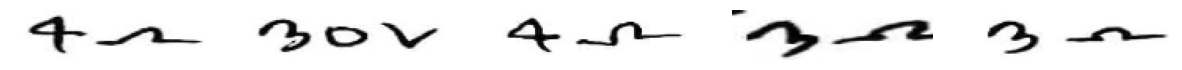

In [20]:
import random
import matplotlib.pyplot as plt
import os
import cv2
import shutil

# Create output dir for saving images
out_dir = "/kaggle/working/crnn_sample_images"
os.makedirs(out_dir, exist_ok=True)

# Randomly pick 5 samples from validation
indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    img = X_val[idx]
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(img, axis=0))
    pred_text = decode_prediction(pred)[0]

    # Save image with GT and prediction in filename
    filename = f"sample_{i+1}_GT-{gt_text}_PR-{pred_text}.png"
    filepath = os.path.join(out_dir, filename)

    cv2.imwrite(filepath, (img.squeeze()*255).astype("uint8"))

print(f"✅ Saved {len(indices)} sample images with GT & predictions to {out_dir}")

# Zip the folder
shutil.make_archive("/kaggle/working/crnn_sample_images", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_sample_images.zip")

# Optional: show the images inline
fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
for ax, idx in zip(axes, indices):
    ax.imshow(X_val[idx].squeeze(), cmap="gray")
    ax.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
✅ Saved 5 sample images with GT & PR written on them to /kaggle/working/crnn_sample_images
📦 Zipped -> /kaggle/working/crnn_sample_images2.zip


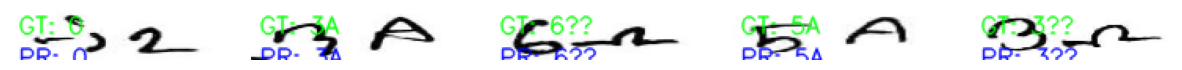

In [21]:
import random
import matplotlib.pyplot as plt
import os
import cv2
import shutil

# Create output dir for saving images
out_dir = "/kaggle/working/crnn_sample_images"
os.makedirs(out_dir, exist_ok=True)

# Randomly pick 5 samples from validation
indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    img = (X_val[idx].squeeze() * 255).astype("uint8")
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(X_val[idx], axis=0))
    pred_text = decode_prediction(pred)[0]

    # Convert to BGR so we can put colored text
    img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Add GT and PR on top of the image
    cv2.putText(img_bgr, f"GT: {gt_text}", (5, 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
    cv2.putText(img_bgr, f"PR: {pred_text}", (5, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

    # Save image
    filename = f"sample_{i+1}.png"
    filepath = os.path.join(out_dir, filename)
    cv2.imwrite(filepath, img_bgr)

print(f"✅ Saved {len(indices)} sample images with GT & PR written on them to {out_dir}")

# Zip the folder
shutil.make_archive("/kaggle/working/crnn_sample_images", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_sample_images2.zip")

# Show them inline
fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
for ax, idx in zip(axes, indices):
    img = cv2.imread(os.path.join(out_dir, f"sample_{indices.index(idx)+1}.png"))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.show()


In [22]:
import os, cv2, shutil
import numpy as np
import matplotlib.pyplot as plt

# Create output folder
out_dir = "/kaggle/working/crnn_val_samples"
os.makedirs(out_dir, exist_ok=True)

# Loop through all validation samples
for i in range(len(X_val)):
    img = (X_val[i].squeeze() * 255).astype("uint8")
    gt_text = y_val_raw[i]

    # Predict
    pred = crnn_model.predict(np.expand_dims(X_val[i], axis=0))
    pred_text = decode_prediction(pred)[0]

    # Create white canvas with extra space on top for GT/PR text
    h, w = img.shape
    canvas = np.ones((h+40, w), dtype="uint8") * 255
    canvas[40:, :] = img

    # Put GT and PR above the image
    cv2.putText(canvas, f"GT: {gt_text}", (5, 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
    cv2.putText(canvas, f"PR: {pred_text}", (5, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

    # Save each sample
    filepath = os.path.join(out_dir, f"val_sample_{i+1}.png")
    cv2.imwrite(filepath, canvas)

print(f"✅ Saved {len(X_val)} validation samples with GT & PR overlays to {out_dir}")

# Zip them for download
shutil.make_archive("/kaggle/working/crnn_val_samples", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_val_samples.zip")

# Show a few inline
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, i in zip(axes, range(5)):
    img = cv2.imread(os.path.join(out_dir, f"val_sample_{i+1}.png"))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
✅ Saved 5 validation samples with GT & PR overlays to /kaggle/working/crnn_val_samples
📦 Zipped -> /kaggle/working/crnn_val_samples.zip


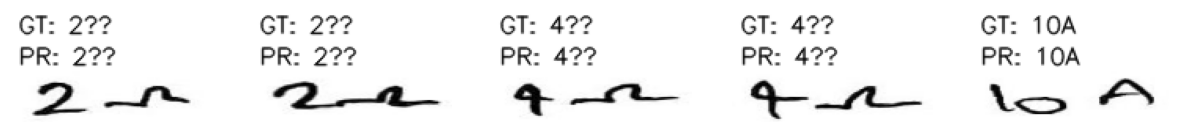

In [24]:
import os, cv2, shutil, random
import numpy as np
import matplotlib.pyplot as plt

# Create output folder
out_dir = "/kaggle/working/crnn_val_samples"
os.makedirs(out_dir, exist_ok=True)

# Pick 5 random indices from validation
indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    img = (X_val[idx].squeeze() * 255).astype("uint8")
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(X_val[idx], axis=0))
    pred_text = decode_prediction(pred)[0]

    # Create white canvas with space for text
    h, w = img.shape
    canvas = np.ones((h+40, w), dtype="uint8") * 255
    canvas[40:, :] = img

    # Add GT and PR above the image
    cv2.putText(canvas, f"GT: {gt_text}", (5, 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
    cv2.putText(canvas, f"PR: {pred_text}", (5, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

    # Save each sample
    filepath = os.path.join(out_dir, f"val_sample_{i+1}.png")
    cv2.imwrite(filepath, canvas)

print(f"✅ Saved {len(indices)} validation samples with GT & PR overlays to {out_dir}")

# Zip them for download
shutil.make_archive("/kaggle/working/crnn_val_samples", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_val_samples.zip")

# Show them inline
fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
for ax, idx in zip(axes, indices):
    img = cv2.imread(os.path.join(out_dir, f"val_sample_{indices.index(idx)+1}.png"))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
✅ Saved 5 validation samples (with Unicode-safe GT/PR text) to /kaggle/working/crnn_val_samples
📦 Zipped -> /kaggle/working/crnn_val_samples.zip


UnidentifiedImageError: cannot identify image file '/kaggle/working/crnn_val_samples/val_sample_1.svg'

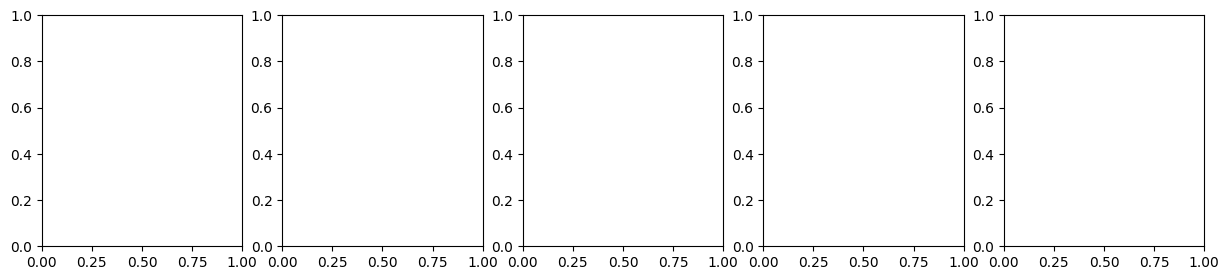

In [25]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt

# Create output folder
out_dir = "/kaggle/working/crnn_val_samples"
os.makedirs(out_dir, exist_ok=True)

# Pick 5 random indices from validation
indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    img = (X_val[idx].squeeze() * 255).astype("uint8")
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(X_val[idx], axis=0))
    pred_text = decode_prediction(pred)[0]

    # Plot with Matplotlib (Unicode safe)
    fig, ax = plt.subplots(figsize=(3, 2))
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    # Add GT and PR above image using Unicode-compatible font
    ax.text(0.5, -0.15, f"GT: {gt_text}", fontsize=10, fontname="DejaVu Sans",
            ha="center", va="center", transform=ax.transAxes)
    ax.text(0.5, -0.3, f"PR: {pred_text}", fontsize=10, fontname="DejaVu Sans",
            ha="center", va="center", transform=ax.transAxes)

    # Save each sample as SVG for sharpness
    filepath = os.path.join(out_dir, f"val_sample_{i+1}.svg")
    plt.savefig(filepath, format="svg", bbox_inches="tight")
    plt.close(fig)

print(f"✅ Saved {len(indices)} validation samples (with Unicode-safe GT/PR text) to {out_dir}")

# Zip them for download
shutil.make_archive("/kaggle/working/crnn_val_samples", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_val_samples.zip")

# Show them inline
fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
for i, ax in enumerate(axes):
    img = plt.imread(os.path.join(out_dir, f"val_sample_{i+1}.svg"))
    ax.imshow(img)
    ax.axis("off")
plt.show()


In [26]:
import os, cv2, shutil, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Create output folder
out_dir = "/kaggle/working/crnn_val_samples"
os.makedirs(out_dir, exist_ok=True)

# Load Unicode-compatible font (DejaVuSans is available in Kaggle)
font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
font = ImageFont.truetype(font_path, size=16)

# Pick 5 random indices from validation
indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    img = (X_val[idx].squeeze() * 255).astype("uint8")
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(X_val[idx], axis=0))
    pred_text = decode_prediction(pred)[0]

    # Create white canvas with space for text
    h, w = img.shape
    canvas = np.ones((h+40, w), dtype="uint8") * 255
    canvas[40:, :] = img

    # Convert to PIL for Unicode text rendering
    pil_img = Image.fromarray(canvas)
    draw = ImageDraw.Draw(pil_img)

    draw.text((5, 5), f"GT: {gt_text}", font=font, fill=0)
    draw.text((5, 25), f"PR: {pred_text}", font=font, fill=0)

    # Save back to OpenCV format
    canvas = np.array(pil_img)
    filepath = os.path.join(out_dir, f"val_sample_{i+1}.png")
    cv2.imwrite(filepath, canvas)

print(f"✅ Saved {len(indices)} validation samples with GT & PR overlays to {out_dir}")

# Zip them for download
shutil.make_archive("/kaggle/working/crnn_val_samples", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_val_samples.zip")

# Show them inline
fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
for ax, i in zip(axes, range(len(indices))):
    img = cv2.imread(os.path.join(out_dir, f"val_sample_{i+1}.png"))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.tight_layout()
plt.show()


OSError: cannot open resource

In [27]:
import os, cv2, shutil, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Create output folder
out_dir = "/kaggle/working/crnn_val_samples"
os.makedirs(out_dir, exist_ok=True)

# ✅ Load Unicode-compatible font (verified path for Kaggle)
font_path = "/usr/share/fonts/dejavu/DejaVuSans.ttf"
font = ImageFont.truetype(font_path, size=16)

# Pick 5 random indices from validation set
indices = random.sample(range(len(X_val)), 5)

for i, idx in enumerate(indices):
    img = (X_val[idx].squeeze() * 255).astype("uint8")
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(X_val[idx], axis=0))
    pred_text = decode_prediction(pred)[0]

    # Create white canvas with space for text
    h, w = img.shape
    canvas = np.ones((h + 40, w), dtype="uint8") * 255
    canvas[40:, :] = img

    # Convert to PIL for Unicode text rendering
    pil_img = Image.fromarray(canvas)
    draw = ImageDraw.Draw(pil_img)

    draw.text((5, 5), f"GT: {gt_text}", font=font, fill=0)
    draw.text((5, 25), f"PR: {pred_text}", font=font, fill=0)

    # Save back to OpenCV format
    canvas = np.array(pil_img)
    filepath = os.path.join(out_dir, f"val_sample_{i+1}.png")
    cv2.imwrite(filepath, canvas)

print(f"✅ Saved {len(indices)} validation samples with GT & PR overlays to {out_dir}")

# Zip them for download
shutil.make_archive("/kaggle/working/crnn_val_samples", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_val_samples.zip")

# Show them inline
fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
for ax, i in zip(axes, range(len(indices))):
    img = cv2.imread(os.path.join(out_dir, f"val_sample_{i+1}.png"))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.tight_layout()
plt.show()


OSError: cannot open resource

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


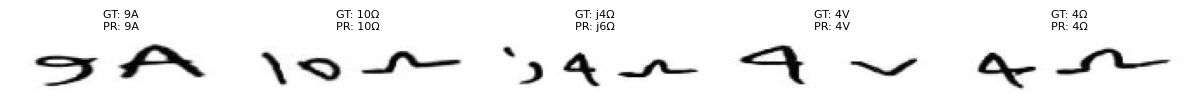

📦 Zipped -> /kaggle/working/crnn_sample_images3.zip


In [33]:
import os, random, shutil
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Create output folder
out_dir = "/kaggle/working/crnn_sample_images3"
os.makedirs(out_dir, exist_ok=True)

# Randomly pick 5 samples from validation
indices = random.sample(range(len(X_val)), 5)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    img = X_val[idx]
    gt_text = y_val_raw[idx]

    # Predict
    pred = crnn_model.predict(np.expand_dims(img, axis=0))
    pred_text = decode_prediction(pred)[0]

    # Plot
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"GT: {gt_text}\nPR: {pred_text}", fontsize=8)
    plt.axis("off")

    # Save image as PNG
    img_uint8 = (img.squeeze() * 255).astype("uint8")
    filepath = os.path.join(out_dir, f"sample_{i+1}.png")
    cv2.imwrite(filepath, img_uint8)

plt.tight_layout()
plt.savefig("/kaggle/working/crnn_sample_predictions.svg", format="svg", bbox_inches="tight")
plt.show()

# Zip the saved images
shutil.make_archive("/kaggle/working/crnn_sample_images3", 'zip', out_dir)
print("📦 Zipped -> /kaggle/working/crnn_sample_images3.zip")
